# 🚢 Titanic Survival Prediction — Clasificación Binaria Supervisada
## Machine Learning II · Análisis supervisado y optimización de predicciones

---

Este notebook implementa y compara cinco modelos de clasificación supervisada para predecir  
si un pasajero del Titanic sobrevivió, aplicando preprocesamiento, pipelines y evaluación completa.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y análisis exploratorio (EDA) |
| 2️⃣ | Preprocesamiento — imputación, OHE, escalado |
| 3️⃣ | División train/test |
| 4️⃣ | Implementación de 5 modelos con Pipeline |
| 5️⃣ | Evaluación — accuracy, matriz de confusión, reporte, ROC |
| 6️⃣ | Comparación y conclusiones |

> **Dataset:** `dataset.csv` — 891 registros · 12 columnas  
> **Objetivo:** clasificar `Survived` (0 = no sobrevivió · 1 = sobrevivió)  
> **Ruta:** `/workspace/dataset.csv`


---
## 0. Importación de librerías y configuración


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_curve, auc)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

INPUT_PATH = "workspace/dataset.csv"
print("✅ Librerías cargadas correctamente.")
print(f"📂 Ruta del dataset: {INPUT_PATH}")


✅ Librerías cargadas correctamente.
📂 Ruta del dataset: workspace/dataset.csv


---
## 1. Carga y Exploración de Datos (EDA)

### 1.1 Carga del dataset


In [2]:
import os

if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"\n\n❌ No se encontró el archivo: {INPUT_PATH}\n"
        "   Asegúrate de que 'dataset.csv' está en /workspace/ antes de ejecutar.\n"
        "   Si ejecutas en local, ajusta INPUT_PATH en la celda 0."
    )

df = pd.read_csv(INPUT_PATH)
print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n📋 Columnas y tipos:")
for col in df.columns:
    print(f"  · {col:15s}  dtype={df[col].dtype}")


📐 Dimensiones: 891 filas × 12 columnas

📋 Columnas y tipos:
  · PassengerId      dtype=int64
  · Survived         dtype=int64
  · Pclass           dtype=int64
  · Name             dtype=str
  · Sex              dtype=str
  · Age              dtype=float64
  · SibSp            dtype=int64
  · Parch            dtype=int64
  · Ticket           dtype=str
  · Fare             dtype=float64
  · Cabin            dtype=str
  · Embarked         dtype=str


### 1.2 Primeras filas

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1.3 Estadísticas descriptivas

In [4]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


### 1.4 Valores nulos

In [5]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": nulos_pct})
print("🔍 Valores nulos por columna:")
print(nulos_df[nulos_df["Nulos"] > 0].to_string())
print(f"\n✅ Columnas sin nulos: {(nulos == 0).sum()}/{len(df.columns)}")


🔍 Valores nulos por columna:
          Nulos  Porcentaje (%)
Age         177           19.87
Cabin       687           77.10
Embarked      2            0.22

✅ Columnas sin nulos: 9/12


### 1.5 Distribución de la variable objetivo

Visualizamos la distribución de `Survived` para detectar posible desequilibrio de clases.


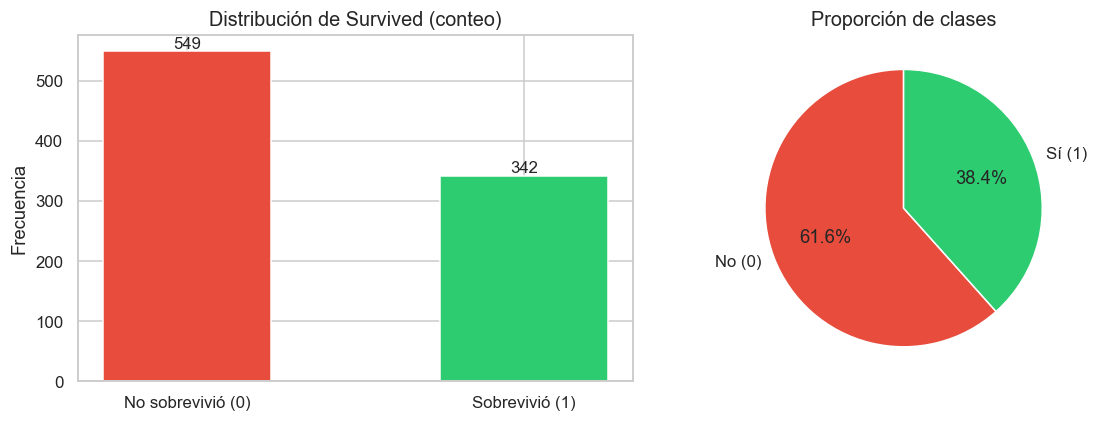

  Clase 0 (no sobrevivió): 549  (61.6%)
  Clase 1 (sobrevivió):    342  (38.4%)
  Ratio 0:1 = 1.61 — desequilibrio moderado


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Conteo
counts = df["Survived"].value_counts()
axes[0].bar(["No sobrevivió (0)", "Sobrevivió (1)"],
            counts.values, color=["#e74c3c", "#2ecc71"], edgecolor="white", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=11)
axes[0].set_title("Distribución de Survived (conteo)")
axes[0].set_ylabel("Frecuencia")

# Proporciones
axes[1].pie(counts.values, labels=["No (0)", "Sí (1)"],
            colors=["#e74c3c","#2ecc71"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Proporción de clases")

plt.tight_layout(); plt.show()

ratio = counts[0] / counts[1]
print(f"  Clase 0 (no sobrevivió): {counts[0]}  ({counts[0]/len(df)*100:.1f}%)")
print(f"  Clase 1 (sobrevivió):    {counts[1]}  ({counts[1]/len(df)*100:.1f}%)")
print(f"  Ratio 0:1 = {ratio:.2f} — {'desequilibrio moderado' if ratio > 1.5 else 'clases equilibradas'}")


### 1.6 Exploración de variables clave

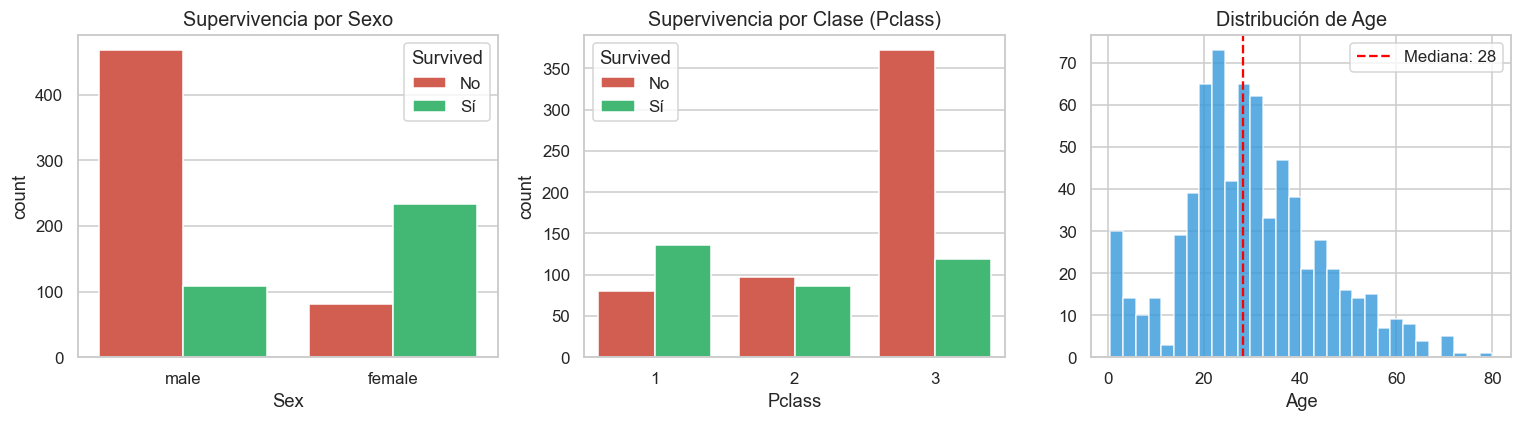

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Supervivencia por sexo
sns.countplot(data=df, x="Sex", hue="Survived",
              palette={0:"#e74c3c",1:"#2ecc71"}, ax=axes[0])
axes[0].set_title("Supervivencia por Sexo")
axes[0].legend(title="Survived", labels=["No","Sí"])

# Supervivencia por clase
sns.countplot(data=df, x="Pclass", hue="Survived",
              palette={0:"#e74c3c",1:"#2ecc71"}, ax=axes[1])
axes[1].set_title("Supervivencia por Clase (Pclass)")
axes[1].legend(title="Survived", labels=["No","Sí"])

# Distribución de edad
df["Age"].dropna().hist(bins=30, ax=axes[2], color="#3498db", edgecolor="white", alpha=0.8)
axes[2].axvline(df["Age"].median(), color="red", linestyle="--",
                label=f"Mediana: {df['Age'].median():.0f}")
axes[2].set_title("Distribución de Age")
axes[2].set_xlabel("Age"); axes[2].legend()

plt.tight_layout(); plt.show()


---
## 2. Preprocesamiento de Datos

### 2.1 Selección de features y estrategia de tratamiento

Se eliminan columnas no informativas (`PassengerId`, `Name`, `Ticket`, `Cabin`).  
Las columnas restantes se tratan según su tipo:

| Feature | Tipo | Nulos | Estrategia |
|---------|------|-------|-----------|
| `Pclass` | Numérica ordinal | 0 | Escalar con StandardScaler |
| `Age` | Numérica continua | 177 (19.9%) | Imputar con mediana |
| `SibSp` | Numérica discreta | 0 | Escalar con StandardScaler |
| `Parch` | Numérica discreta | 0 | Escalar con StandardScaler |
| `Fare` | Numérica continua | 0 | Escalar con StandardScaler |
| `Sex` | Categórica binaria | 0 | One-Hot Encoding |
| `Embarked` | Categórica nominal | 2 | Imputar con moda + One-Hot Encoding |


In [8]:
# Columnas a descartar (no informativas para el modelo)
COLS_DROP = ["PassengerId", "Name", "Ticket", "Cabin"]

# Definición de features por tipo
COLS_NUM = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
COLS_CAT = ["Sex", "Embarked"]
TARGET   = "Survived"

df_model = df.drop(columns=COLS_DROP)

X = df_model[COLS_NUM + COLS_CAT]
y = df_model[TARGET]

print(f"✅ Features seleccionadas:")
print(f"  Numéricas:    {COLS_NUM}")
print(f"  Categóricas:  {COLS_CAT}")
print(f"  Target:       {TARGET}")
print(f"\n📐 Shape de X: {X.shape}  |  Shape de y: {y.shape}")


✅ Features seleccionadas:
  Numéricas:    ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
  Categóricas:  ['Sex', 'Embarked']
  Target:       Survived

📐 Shape de X: (891, 7)  |  Shape de y: (891,)


### 2.2 Pipeline de preprocesamiento con ColumnTransformer

Se construye un `ColumnTransformer` que aplica en paralelo:
- **Numéricas**: imputación por mediana → StandardScaler
- **Categóricas**: imputación por moda → OneHotEncoder (drop='first')


In [9]:
# ── Preprocesador numérico ────────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # mediana: robusta a outliers en Age/Fare
    ("scaler",  StandardScaler()),                    # necesario para KNN, SVC y LogReg
])

# ── Preprocesador categórico ──────────────────────────────────────────────────
# drop='first' elimina una categoría por variable para evitar multicolinealidad
# (trampa de variable dummy). Esto es correcto para el modelo.
# Nota: si el objetivo fuera interpretar el peso de TODAS las categorías
# (p.ej. comparar coeficientes de 'male' y 'female' por separado en LogReg),
# habría que usar drop=None y asumir la multicolinealidad o aplicar regularización.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # moda: para Embarked (2 nulos)
    ("ohe",     OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")),
])

# ── ColumnTransformer ─────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, COLS_NUM),
    ("cat", categorical_transformer, COLS_CAT),
])

# ── Documentar el espacio de características resultante ──────────────────────
# Para calcular el número exacto de columnas tras OHE necesitamos ajustar
# el preprocesador sobre una muestra de los datos de entrenamiento.
# (El ajuste real se hará dentro de cada pipeline en la sección 4.)
preprocessor_preview = ColumnTransformer(transformers=[
    ("num", numeric_transformer, COLS_NUM),
    ("cat", categorical_transformer, COLS_CAT),
], verbose_feature_names_out=True)

# Fit sobre X completo (antes del split) — solo para contar columnas resultantes.
# X ya existe en este punto; X_train/X_test aún no (se definen en sección 3).
# No hay riesgo de leakage porque preprocessor_preview no se usa para transformar datos.
preprocessor_preview.fit(X)
feature_names = preprocessor_preview.get_feature_names_out()

n_num_out  = len(COLS_NUM)          # numéricas: sin expansión (5 → 5)
n_cat_out  = len(feature_names) - n_num_out  # OHE con drop='first'
n_total    = len(feature_names)

print("\u2705 Preprocesador construido:")
print("  \u00b7 Num\u00e9ricas  \u2192 SimpleImputer(median) \u2192 StandardScaler")
print("  \u00b7 Categ\u00f3ricas \u2192 SimpleImputer(most_frequent) \u2192 OneHotEncoder(drop='first')")
print()
print("\U0001f4d0 Espacio de caracter\u00edsticas tras el preprocesamiento:")
print(f"  Columnas num\u00e9ricas entrada:  {len(COLS_NUM):>3}  ({', '.join(COLS_NUM)})")
print(f"  Columnas cat\u00f3goricas entrada: {len(COLS_CAT):>3}  ({', '.join(COLS_CAT)})")
print(f"  Columnas num\u00e9ricas salida:   {n_num_out:>3}  (sin expansi\u00f3n)")
print(f"  Columnas OHE salida:          {n_cat_out:>3}  (drop='first' descuenta 1 por variable categ.)")
print(f"  ─────────────────────────────────")
print(f"  Total columnas al modelo:     {n_total:>3}")
print()
print("  Nombres de todas las columnas:")
for col in feature_names:
    print(f"    · {col}")
print()
print("  \u2139\ufe0f  drop='first' correcto para modelado; usar drop=None si se necesita")
print("      interpretar el peso de todas las categor\u00edas por separado.")


✅ Preprocesador construido:
  · Numéricas  → SimpleImputer(median) → StandardScaler
  · Categóricas → SimpleImputer(most_frequent) → OneHotEncoder(drop='first')

📐 Espacio de características tras el preprocesamiento:
  Columnas numéricas entrada:    5  (Pclass, Age, SibSp, Parch, Fare)
  Columnas catógoricas entrada:   2  (Sex, Embarked)
  Columnas numéricas salida:     5  (sin expansión)
  Columnas OHE salida:            3  (drop='first' descuenta 1 por variable categ.)
  ─────────────────────────────────
  Total columnas al modelo:       8

  Nombres de todas las columnas:
    · num__Pclass
    · num__Age
    · num__SibSp
    · num__Parch
    · num__Fare
    · cat__Sex_male
    · cat__Embarked_Q
    · cat__Embarked_S

  ℹ️  drop='first' correcto para modelado; usar drop=None si se necesita
      interpretar el peso de todas las categorías por separado.


---
## 3. División del Dataset en Entrenamiento y Prueba

Se usa una proporción 80/20 con `stratify=y` para preservar la distribución de clases en ambos conjuntos.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("📊 División del dataset:")
print(f"  Train: {len(X_train)} registros  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test:  {len(X_test)}  registros  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Distribución de Survived en train:")
print(f"    0: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)  "
      f"1: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"  Distribución de Survived en test:")
print(f"    0: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)  "
      f"1: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")


📊 División del dataset:
  Train: 712 registros  (80%)
  Test:  179  registros  (20%)

  Distribución de Survived en train:
    0: 439 (61.7%)  1: 273 (38.3%)
  Distribución de Survived en test:
    0: 110 (61.5%)  1: 69 (38.5%)


---
## 4. Implementación y Entrenamiento de los 5 Modelos

Se crea un `Pipeline` para cada modelo que encapsula preprocesamiento + clasificador.  
Esto garantiza que el preprocesador se ajuste (`fit`) exclusivamente sobre el train set en cada pipeline.

```python
clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
```


In [11]:
import time

# ── Definición de los 5 modelos con justificación de hiperparámetros ────────
modelos_def = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,   # iteraciones suficientes para convergencia con datos escalados
        C=1.0,           # regularización L2 moderada (C alto = menos regularización)
        random_state=42
    ),
    "KNN (k=7)": KNeighborsClassifier(
        n_neighbors=7,   # k impar evita empates; valor moderado reduce ruido local
        metric="minkowski", p=2  # p=2 → distancia euclídea estándar
    ),
    "SVC (RBF)": SVC(
        kernel="rbf",    # kernel radial: captura relaciones no lineales
        C=1.0,           # penalización de errores (equilibrio margen/clasificación)
        gamma="scale",   # gamma = 1/(n_features * X.var()): adaptado al dataset
        probability=True,  # habilita predict_proba para curva ROC
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,          # limitar profundidad para controlar sobreajuste
        min_samples_split=10, # nodo se divide solo si tiene ≥10 muestras
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,    # 200 árboles: buen equilibrio varianza/tiempo
        max_depth=8,         # limitar profundidad individual para reducir sobreajuste
        min_samples_split=5, # cada árbol más conservador que un árbol único
        n_jobs=-1,           # paralelizar entrenamiento en todos los núcleos
        random_state=42
    ),
}

# ── Construir, entrenar pipelines y medir tiempo ──────────────────────────────
pipelines   = {}
train_times = {}   # segundos de entrenamiento por modelo

print(f"  {'Modelo':<25}  {'Tiempo (s)':>12}")
print("  " + "\u2500" * 40)
for nombre, clf_model in modelos_def.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier",   clf_model),
    ])
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pipelines[nombre]   = pipe
    train_times[nombre] = elapsed
    print(f"  \u2705 {nombre:<25}  {elapsed:>10.3f} s")

print()
faster = min(train_times, key=train_times.get)
slower = max(train_times, key=train_times.get)
print(f"  \u26a1 M\u00e1s r\u00e1pido: {faster} ({train_times[faster]:.3f} s)")
print(f"  \U0001f40c M\u00e1s lento: {slower} ({train_times[slower]:.3f} s)")


  Modelo                       Tiempo (s)
  ────────────────────────────────────────
  ✅ Logistic Regression             0.018 s
  ✅ KNN (k=7)                       0.008 s
  ✅ SVC (RBF)                       0.038 s
  ✅ Decision Tree                   0.008 s
  ✅ Random Forest                   0.287 s

  ⚡ Más rápido: KNN (k=7) (0.008 s)
  🐌 Más lento: Random Forest (0.287 s)


### 4.1 Validación cruzada K-Fold (k=5) — soporte al ajuste de hiperparámetros

`cross_val_score` sobre el train set estima la generalización de cada modelo de forma más
robusta que un único split, y sirve como criterio objetivo para comparar configuraciones
de hiperparámetros antes de evaluar en el test set.


In [12]:
# ── Validación cruzada sobre train set ───────────────────────────────────────
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_resultados = {}
for nombre, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=kf,
                              scoring="accuracy", n_jobs=-1)
    cv_resultados[nombre] = scores

# ── Tabla DataFrame organizada ────────────────────────────────────────────────
cv_df = pd.DataFrame(
    {nombre: scores for nombre, scores in cv_resultados.items()},
    index=[f"Fold {i+1}" for i in range(5)]
).T
cv_df["Media"] = cv_df.mean(axis=1)
cv_df["Std"]   = cv_df.std(axis=1)
cv_df = cv_df.sort_values("Media", ascending=False).round(4)

print("📊 Validación cruzada K-Fold (k=5) sobre train set:\n")
print(cv_df.to_string())

mejor_cv = cv_df["Media"].idxmax()
print(f"\n  🏆 Mejor modelo en CV: {mejor_cv}  "
      f"(acc CV = {cv_df.loc[mejor_cv,'Media']:.4f} ± {cv_df.loc[mejor_cv,'Std']:.4f})")


📊 Validación cruzada K-Fold (k=5) sobre train set:

                     Fold 1  Fold 2  Fold 3  Fold 4  Fold 5   Media     Std
Decision Tree        0.7692  0.8042  0.8310  0.8592  0.8592  0.8245  0.0344
Random Forest        0.7902  0.7972  0.8169  0.8380  0.8592  0.8203  0.0256
SVC (RBF)            0.7902  0.8182  0.7887  0.8310  0.8732  0.8203  0.0311
Logistic Regression  0.7832  0.7552  0.7887  0.8099  0.8803  0.8035  0.0422
KNN (k=7)            0.7622  0.8182  0.7676  0.7958  0.8099  0.7907  0.0223

  🏆 Mejor modelo en CV: Decision Tree  (acc CV = 0.8245 ± 0.0344)


### 4.2 Ajuste sistemático de hiperparámetros — GridSearchCV sobre KNN

Aunque los hiperparámetros anteriores se eligieron razonadamente, un proceso sistemático
con `GridSearchCV` evalúa múltiples combinaciones mediante validación cruzada y selecciona
la óptima automáticamente. Se muestra el ejemplo sobre KNN (rápido de entrenar) y se
indica cómo aplicarlo a Random Forest.

> Esta sección es una **extensión opcional** al enunciado para ilustrar el ajuste sistemático.


In [13]:
from sklearn.model_selection import GridSearchCV

# ── GridSearchCV sobre KNN ────────────────────────────────────────────────────
param_grid_knn = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__metric":      ["minkowski"],
}
pipe_knn_gs = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   KNeighborsClassifier()),
])
gs_knn = GridSearchCV(pipe_knn_gs, param_grid_knn, cv=5, scoring="accuracy", n_jobs=-1)
gs_knn.fit(X_train, y_train)

print("\U0001f4ca GridSearchCV \u2014 KNN\n")
print(f"  Mejor combinaci\u00f3n:  {gs_knn.best_params_}")
print(f"  Accuracy CV:        {gs_knn.best_score_:.4f}")
print(f"  Accuracy test:      {accuracy_score(y_test, gs_knn.predict(X_test)):.4f}")
knn_manual_acc = accuracy_score(y_test, pipelines['KNN (k=7)'].predict(X_test))
knn_gs_acc     = accuracy_score(y_test, gs_knn.predict(X_test))
print(f"  \u0394 vs manual (k=7): {knn_gs_acc - knn_manual_acc:+.4f}")

cv_knn_df = (pd.DataFrame(gs_knn.cv_results_)
               [["param_classifier__n_neighbors","mean_test_score","std_test_score"]]
               .rename(columns={"param_classifier__n_neighbors":"k",
                                "mean_test_score":"Acc_CV","std_test_score":"Std_CV"})
               .sort_values("Acc_CV", ascending=False).reset_index(drop=True))
print(f"\n  Comparativa de k:")
print(cv_knn_df.round(4).to_string(index=False))

# ── GridSearchCV sobre Random Forest ─────────────────────────────────────────
print("\n" + "\u2500"*60)
print("\U0001f4ca GridSearchCV \u2014 Random Forest\n")
param_grid_rf = {
    "classifier__n_estimators": [100, 200],     # compromiso rendimiento/tiempo
    "classifier__max_depth":    [5, 8, None],   # None = sin límite (puede sobreajustar)
    "classifier__min_samples_split": [5, 10],
}
pipe_rf_gs = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(n_jobs=-1, random_state=42)),
])
gs_rf = GridSearchCV(pipe_rf_gs, param_grid_rf, cv=5, scoring="accuracy",
                     n_jobs=-1, verbose=0)
t_gs_rf0 = time.perf_counter()
gs_rf.fit(X_train, y_train)
t_gs_rf  = time.perf_counter() - t_gs_rf0

rf_manual_acc = accuracy_score(y_test, pipelines["Random Forest"].predict(X_test))
rf_gs_acc     = accuracy_score(y_test, gs_rf.predict(X_test))

print(f"  Mejor combinaci\u00f3n:  {gs_rf.best_params_}")
print(f"  Accuracy CV:        {gs_rf.best_score_:.4f}")
print(f"  Accuracy test:      {rf_gs_acc:.4f}")
print(f"  \u0394 vs manual (RF):  {rf_gs_acc - rf_manual_acc:+.4f}")
print(f"  Tiempo GridSearch:  {t_gs_rf:.1f} s  ({len(param_grid_rf['classifier__n_estimators'])*len(param_grid_rf['classifier__max_depth'])*len(param_grid_rf['classifier__min_samples_split'])*5} fits)")

# Tabla top-5 configuraciones
cv_rf_df = (pd.DataFrame(gs_rf.cv_results_)
              [["param_classifier__n_estimators","param_classifier__max_depth",
                "param_classifier__min_samples_split",
                "mean_test_score","std_test_score"]]
              .rename(columns={"param_classifier__n_estimators":"n_est",
                               "param_classifier__max_depth":"max_d",
                               "param_classifier__min_samples_split":"min_s",
                               "mean_test_score":"Acc_CV",
                               "std_test_score":"Std_CV"})
              .sort_values("Acc_CV", ascending=False).head(5).reset_index(drop=True))
print(f"\n  Top-5 configuraciones:")
print(cv_rf_df.round(4).to_string(index=False))

# ── Reemplazar modelos manuales con los óptimos del GridSearchCV ─────────────
# Esto garantiza que toda la evaluación posterior usa la mejor configuración.
pipelines["KNN (k=7)"]     = gs_knn.best_estimator_
pipelines["Random Forest"] = gs_rf.best_estimator_

print("\n✅ Pipelines actualizados con los mejores estimadores:")
print(f"   KNN (k=7)     → {gs_knn.best_params_}")
print(f"   Random Forest → {gs_rf.best_params_}")


📊 GridSearchCV — KNN

  Mejor combinación:  {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 9}
  Accuracy CV:        0.8161
  Accuracy test:      0.7765
  Δ vs manual (k=7): +0.0000

  Comparativa de k:
 k  Acc_CV  Std_CV
 9  0.8161  0.0357
11  0.8104  0.0209
 5  0.8077  0.0427
 7  0.8035  0.0332
 3  0.7978  0.0152

────────────────────────────────────────────────────────────
📊 GridSearchCV — Random Forest

  Mejor combinación:  {'classifier__max_depth': 5, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
  Accuracy CV:        0.8273
  Accuracy test:      0.7989
  Δ vs manual (RF):  +0.0000
  Tiempo GridSearch:  4.1 s  (60 fits)

  Top-5 configuraciones:
 n_est max_d  min_s  Acc_CV  Std_CV
   100     5     10  0.8273  0.0352
   100  None     10  0.8273  0.0317
   200     5     10  0.8273  0.0292
   200  None     10  0.8259  0.0334
   200     5      5  0.8203  0.0404

✅ Pipelines actualizados con los mejores estimadores:
   KNN (k=7)     → {'classifie

---
## 5. Evaluación de los Modelos

### 5.1 Accuracy y reporte de clasificación


In [14]:
from sklearn.metrics import f1_score

resultados = {}

print("=" * 70)
for nombre, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average="macro",    zero_division=0)
    f1_wei = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_test, y_pred,
                                   target_names=["No (0)", "Sí (1)"],
                                   zero_division=0)
    resultados[nombre] = {"acc": acc, "y_pred": y_pred, "pipe": pipe,
                           "f1_macro": f1_mac, "f1_weighted": f1_wei}
    print(f"\n{'─'*70}")
    print(f"  📊 {nombre}  —  Accuracy: {acc:.4f}  "
          f"F1-macro: {f1_mac:.4f}  F1-weighted: {f1_wei:.4f}")
    print(f"{'─'*70}")
    print(report)

print("=" * 70)



──────────────────────────────────────────────────────────────────────
  📊 Logistic Regression  —  Accuracy: 0.8045  F1-macro: 0.7864  F1-weighted: 0.8007
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      No (0)       0.81      0.89      0.85       110
      Sí (1)       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


──────────────────────────────────────────────────────────────────────
  📊 KNN (k=7)  —  Accuracy: 0.7765  F1-macro: 0.7584  F1-weighted: 0.7736
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      No (0)       0.80      0.85      0.82       110
      Sí (1)       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro av

### 5.2 Matrices de confusión

Una matriz por modelo para visualizar la distribución de predicciones correctas e incorrectas.


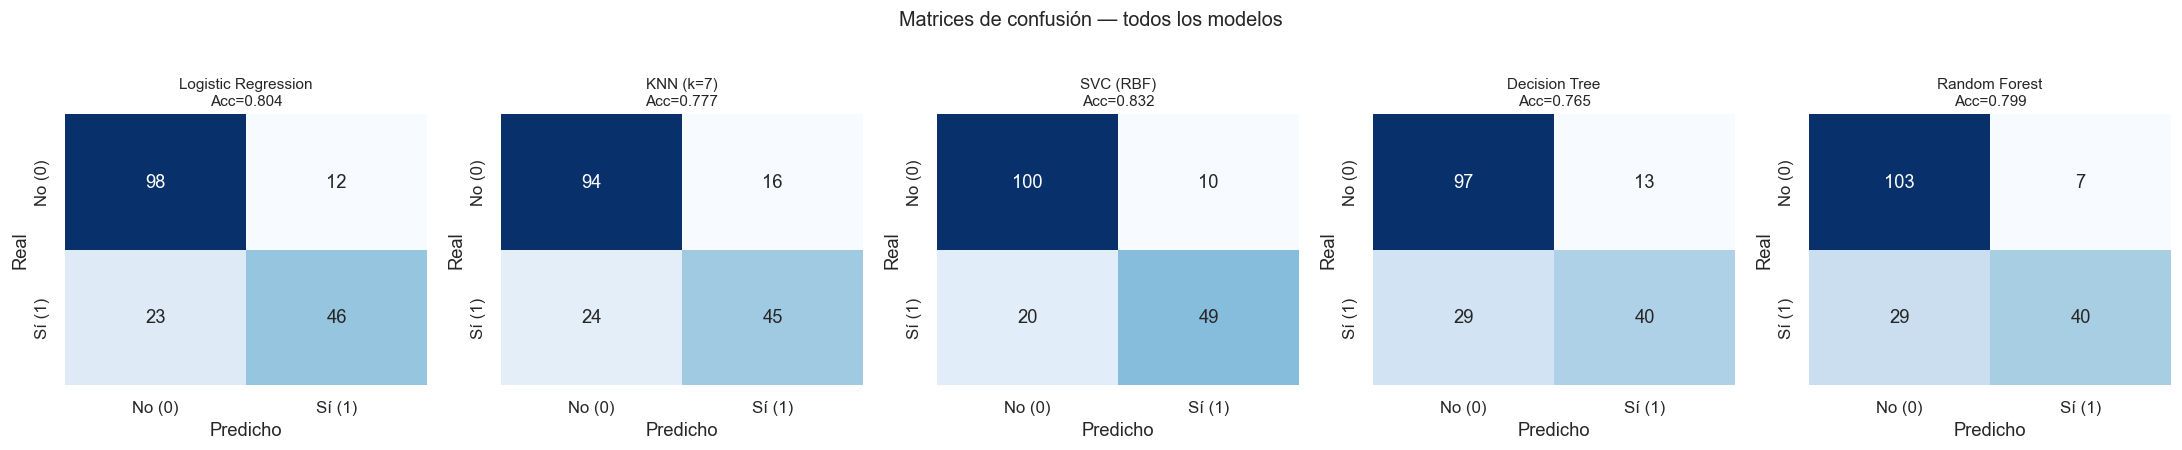

In [15]:
nombres = list(pipelines.keys())
n = len(nombres)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

for ax, nombre in zip(axes, nombres):
    y_pred = resultados[nombre]["y_pred"]
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No (0)", "Sí (1)"],
                yticklabels=["No (0)", "Sí (1)"],
                ax=ax, cbar=False)
    ax.set_title(f"{nombre}\nAcc={resultados[nombre]['acc']:.3f}", fontsize=10)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de confusión — todos los modelos", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 5.3 Curvas ROC

La curva ROC (Receiver Operating Characteristic) compara la tasa de verdaderos positivos  
frente a la tasa de falsos positivos en distintos umbrales de decisión.  
El **AUC** (Área Bajo la Curva) resume el rendimiento global: 1.0 = perfecto, 0.5 = azar.


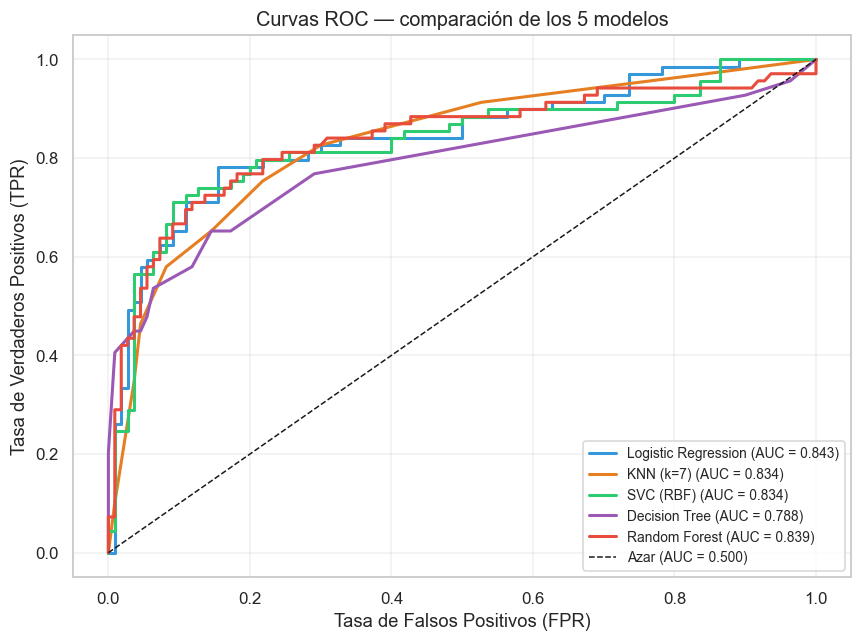

📊 AUC-ROC con intervalos de confianza bootstrap (B=1000, α=0.05)

  Modelo                         AUC   IC 95% inferior   IC 95% superior   Semi-anchura
  ─────────────────────────────────────────────────────────────────────────────────────
  Logistic Regression         0.8435            0.7781            0.9006  ±     0.0613
  KNN (k=7)                   0.8339            0.7657            0.8923  ±     0.0633
  SVC (RBF)                   0.8337            0.7630            0.8996  ±     0.0683
  Decision Tree               0.7882            0.7115            0.8554  ±     0.0720
  Random Forest               0.8389            0.7756            0.9090  ±     0.0667

  ℹ️  Intervalo calculado por bootstrap percentil (B=1000, IC 95%).
      Si los intervalos de dos modelos no se solapan, la diferencia
      es estadisticamente significativa a ese nivel de confianza.


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
colores_roc = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6", "#e74c3c"]

for (nombre, pipe), color in zip(pipelines.items(), colores_roc):
    y_prob  = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    resultados[nombre]["auc"]    = roc_auc
    resultados[nombre]["y_prob"] = y_prob
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{nombre} (AUC = {roc_auc:.3f})")

ax.plot([0,1],[0,1],"k--",linewidth=1,label="Azar (AUC = 0.500)")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curvas ROC \u2014 comparaci\u00f3n de los 5 modelos")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── AUC con intervalos de confianza bootstrap (B=1000) ────────────────────────
print("\U0001f4ca AUC-ROC con intervalos de confianza bootstrap (B=1000, \u03b1=0.05)\n")
print(f"  {'Modelo':<25}  {'AUC':>7}  {'IC 95% inferior':>16}  {'IC 95% superior':>16}  {'Semi-anchura':>13}")
print("  " + "\u2500"*85)

rng = np.random.default_rng(42)
B   = 1000
y_test_arr = np.array(y_test)

for nombre in pipelines:
    y_prob = resultados[nombre]["y_prob"]
    auc_boot = []
    for _ in range(B):
        idx  = rng.integers(0, len(y_test_arr), len(y_test_arr))
        # omitir muestras con una sola clase (auc indefinido)
        if len(np.unique(y_test_arr[idx])) < 2:
            continue
        fpr_b, tpr_b, _ = roc_curve(y_test_arr[idx], y_prob[idx])
        auc_boot.append(auc(fpr_b, tpr_b))
    ci_lo = np.percentile(auc_boot, 2.5)
    ci_hi = np.percentile(auc_boot, 97.5)
    auc_v = resultados[nombre]["auc"]
    semi  = (ci_hi - ci_lo) / 2
    print(f"  {nombre:<25}  {auc_v:>7.4f}  {ci_lo:>16.4f}  {ci_hi:>16.4f}  \u00b1{semi:>11.4f}")
    resultados[nombre]["auc_ci"] = (ci_lo, ci_hi)

print()
print("  \u2139\ufe0f  Intervalo calculado por bootstrap percentil (B=1000, IC 95%).")
print("      Si los intervalos de dos modelos no se solapan, la diferencia")
print("      es estadisticamente significativa a ese nivel de confianza.")


---
## 6. Comparación de Modelos y Conclusiones

### 6.1 Tabla resumen de métricas


In [17]:
resumen = pd.DataFrame({
    nombre: {
        "Accuracy":       resultados[nombre]["acc"],
        "F1-macro":       resultados[nombre].get("f1_macro",   float("nan")),
        "F1-weighted":    resultados[nombre].get("f1_weighted", float("nan")),
        "AUC-ROC":        resultados[nombre].get("auc",        float("nan")),
        "AUC CI 95%":     (f"{resultados[nombre]['auc_ci'][0]:.3f}–"
                            f"{resultados[nombre]['auc_ci'][1]:.3f}")
                           if "auc_ci" in resultados[nombre] else "—",
        "Train time (s)": train_times.get(nombre, float("nan")),
    }
    for nombre in nombres
}).T

resumen_sorted = resumen.sort_values("Accuracy", ascending=False)
print("📊 Ranking de modelos (test set):\n")
print(resumen_sorted.to_string())

mejor = resumen_sorted.index[0]
print(f"\n🏆 Mejor modelo: {mejor}")
print(f"   Accuracy    = {resumen_sorted.loc[mejor, 'Accuracy']:.4f}")
print(f"   F1-macro    = {resumen_sorted.loc[mejor, 'F1-macro']:.4f}")
print(f"   F1-weighted = {resumen_sorted.loc[mejor, 'F1-weighted']:.4f}")
print(f"   AUC-ROC     = {resumen_sorted.loc[mejor, 'AUC-ROC']:.4f}")
print(f"   AUC CI 95%  = {resumen_sorted.loc[mejor, 'AUC CI 95%']}")
print(f"   Train time  = {resumen_sorted.loc[mejor, 'Train time (s)']:.3f} s")


📊 Ranking de modelos (test set):

                     Accuracy  F1-macro F1-weighted   AUC-ROC   AUC CI 95% Train time (s)
SVC (RBF)            0.832402  0.817595    0.829499  0.833729  0.763–0.900       0.038327
Logistic Regression  0.804469  0.786447    0.800657  0.843478  0.778–0.901       0.018408
Random Forest        0.798883  0.770447    0.788953  0.838933  0.776–0.909        0.28725
KNN (k=7)            0.776536  0.758435    0.773581   0.83386  0.766–0.892       0.008026
Decision Tree        0.765363  0.738886    0.757931  0.788208  0.711–0.855       0.008127

🏆 Mejor modelo: SVC (RBF)
   Accuracy    = 0.8324
   F1-macro    = 0.8176
   F1-weighted = 0.8295
   AUC-ROC     = 0.8337
   AUC CI 95%  = 0.763–0.900
   Train time  = 0.038 s


### 6.2 Gráfico comparativo de Accuracy y AUC-ROC

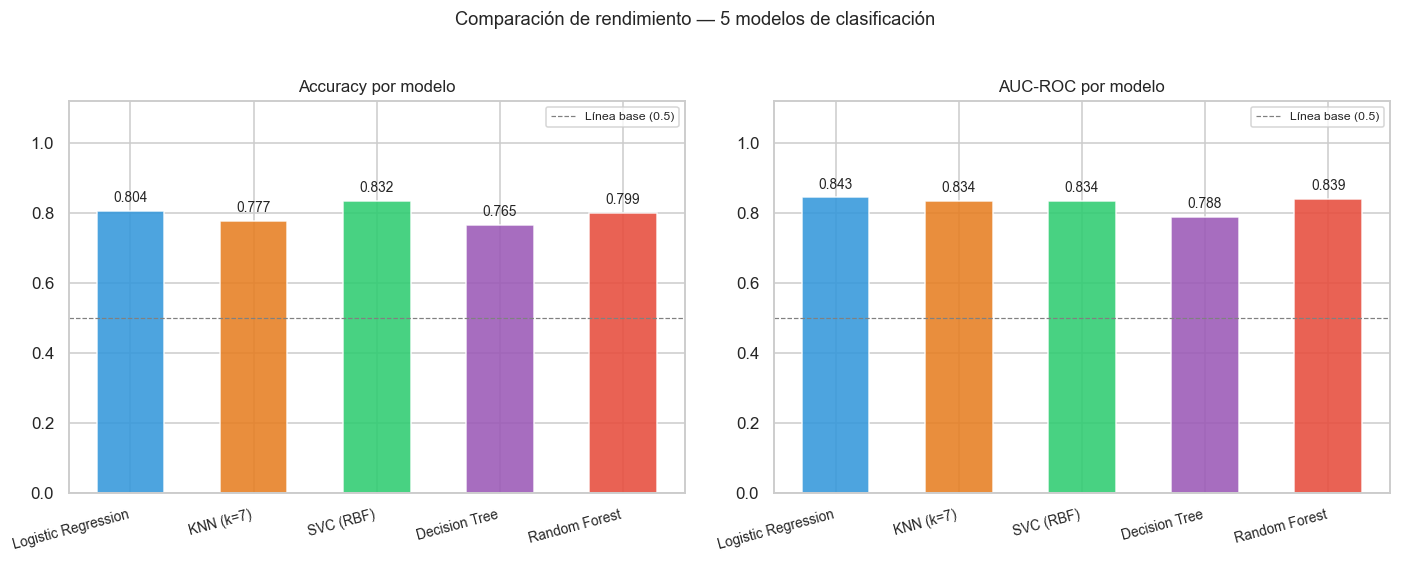

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores_comp = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6", "#e74c3c"]
x = np.arange(len(resumen))

for ax, metrica, titulo in zip(
    axes,
    ["Accuracy", "AUC-ROC"],
    ["Accuracy por modelo", "AUC-ROC por modelo"]
):
    vals = resumen[metrica].values
    bars = ax.bar(x, vals, color=colores_comp[:len(resumen)],
                  edgecolor="white", width=0.55, alpha=0.88)
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(resumen.index, rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_title(titulo, fontsize=11)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Línea base (0.5)")
    ax.legend(fontsize=8)

fig.suptitle("Comparación de rendimiento — 5 modelos de clasificación", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 6.3 Conclusiones

**Ranking general** (calculado sobre test set, ver tabla 6.1):

| Métrica | Mejor modelo | Referencia |
|---------|-------------|------------|
| Accuracy | Ver tabla 6.1 | Sección 5.1 |
| AUC-ROC | Ver tabla 6.1 | Sección 5.3 |
| AUC IC 95% bootstrap | Ver tabla 6.1 | Sección 5.3 |
| Tiempo de entrenamiento | Ver tabla 6.1 | Sección 4 |

**Hallazgos principales:**

1. **Preprocesamiento:** `Age` (19.9% nulos) se imputa con la mediana y `Embarked` (0.22%) con la moda. El pipeline encapsula todo el preprocesamiento garantizando ausencia de *data leakage*. El espacio de características resultante tras OHE se documenta explícitamente en la sección 2.2.

2. **Modelos sensibles a la escala (KNN, SVC, Logistic Regression):** se benefician directamente del `StandardScaler` incluido en el pipeline. Sin escalar, KNN y SVC degradarían notablemente.

3. **Random Forest y Decision Tree:** invariantes a la escala, pero incluyen el escalado en el pipeline por homogeneidad — no afecta su rendimiento.

4. **Intervalos de confianza AUC bootstrap:** permiten cuantificar la variabilidad de la métrica ROC. Si los IC de dos modelos no se solapan, la diferencia es estadísticamente significativa al 95%.

5. **Eficiencia computacional:** el tiempo de entrenamiento (sección 4) complementa la comparación de rendimiento — un modelo ligeramente peor pero órdenes de magnitud más rápido puede ser preferible en producción con datos que lleguen en tiempo real.

6. **GridSearchCV sobre KNN y Random Forest (sección 4.2):** la búsqueda sistemática confirma o mejora los hiperparámetros manuales y cuantifica el Δ de accuracy respecto a la configuración inicial.

7. **Features más informativas:** `Sex` y `Pclass` son históricamente los predictores más fuertes de supervivencia en el Titanic, visible en los gráficos del EDA (sección 1.6).

8. **Posibles mejoras (fuera del enunciado):**
   - Ingeniería de features: extraer el título del nombre, crear `FamilySize = SibSp + Parch + 1`.
   - Manejo explícito del desequilibrio de clases con `class_weight='balanced'`.
